## Постановка задачи

Рассматривается задача бинарной классификации: предсказание способности системы к образованию кристалла (cryst = 1) или её отсутствия (cryst = 0).

Задача характеризуется дисбалансом классов: доля положительного класса существенно ниже.

In [11]:
from pathlib import Path
import sys

root = Path('..').resolve()
if str(root) not in sys.path:
    sys.path.append(str(root))

import pandas as pd
import matplotlib.pyplot as plt
import pickle
import numpy as np

from src.models.train_eval import train_optuna_xgb, test

In [12]:
train_df = pd.read_pickle(root / 'data' / 'final' / 'triple_real_xtb.pkl')
holdout_df = pd.read_pickle(root / 'data' / 'final' / 'holdout_rebuilt_xtb.pkl')
sulf_df = pd.read_pickle(root / 'data' / 'final' / 'sulf_rebuilt_xtb.pkl')

## Признаковое пространство

В качестве признаков используются векторные представления молекулярных систем (`xtb_concat`).

Каждый объект представлен числовым вектором фиксированной размерности, формируемым путём объединения дескрипторов.

Рассматриваются два варианта признаков:
- реальные 3D-геометрии
- геометрии, восстановленные из 2D-представлений

Таргет - колонка cryst
- 1 - образуют кристалл
- 0 - не образуют кристалл

In [13]:
train_df.head(2)

,source_file,formula_1,xyz_1_3d,formula_2,xyz_2_3d,formula_3,xyz_3_3d,xtb_1_3d,xtb_2_3d,xtb_3_3d,xtb_concat_3d,cryst
0,GATCAH,GdC46N6(ClO4)2,126\nGd2 C92 N12 Cl4 O16\nC -1.911545 2.376586...,C3NO,5\nC3 N1 O1\nC -0.400809 -0.551343 -0.789440\n...,ClO4,5\nCl1 O4\nO -1.098584 0.802731 0.395786\nO -0...,"[1.0, 1.0, -314.9685994404997, 126.0, -2.49975...","[1.0, 1.0, -13.22904652994901, 5.0, -2.6458093...","[1.0, 1.0, -20.39468970230421, 5.0, -4.0789379...","[1.0, 1.0, -314.9686, 126.0, -2.4997509, 7.076...",1
1,ZESSUL,EuC24(N2O3)2,70\nEu2 C48 N8 O12\nO 0.797972 1.673834 -0.006...,C5N,12\nC10 N2\nC -2.795876 -0.601193 0.610952\nC ...,ClO4,5\nCl1 O4\nO 1.375560 -0.122040 0.309645\nO -0...,"[1.0, 1.0, -175.22370355489122, 70.0, -2.50319...","[1.0, 1.0, -26.738125111357956, 12.0, -2.22817...","[1.0, 1.0, -20.394692431724913, 5.0, -4.078938...","[1.0, 1.0, -175.22371, 70.0, -2.5031958, 4.955...",1


In [14]:
holdout_df.head(2)

,source_file,A,B,G,formula_1,xyz_1_3d,xyz_1_rebuilt,formula_2,xyz_2_3d,xyz_2_rebuilt,...,xyz_3_rebuilt,xtb_1_3d,xtb_2_3d,xtb_3_3d,xtb_concat_3d,xtb_1_rebuilt,xtb_2_rebuilt,xtb_3_rebuilt,xtb_concat_rebuilt,cryst
0,KAVDUH,[C]1=[C]N=[C][C]=C1[C][C]C1=[C][C]=N[C]=[C]1,[C]1=[C]N=[C][C]=C1C1=[C][C]=N[C]=[C]1,[C]1([C][C]([C][C]([C]1)C(=O)[O])C(=O)[O])C(=O...,C6N,14\nC12 N2\nC -0.666438 -0.377071 -1.611984\nC...,14\n\nC -0.329258 2.778546 1.265276\nC -0.1065...,C5N,12\nC10 N2\nC 1.671000 0.886041 -0.041496\nC -...,12\n\nC -0.800682 0.286870 0.693768\nC -1.2194...,...,15\n\nC -0.671322 -1.699487 0.745252\nC -1.496...,"[1.0, 1.0, -30.90953187810369, 14.0, -2.207823...","[1.0, 1.0, -26.689396312593143, 12.0, -2.22411...","[1.0, 1.0, -43.33954927182332, 15.0, -2.889303...","[1.0, 1.0, -30.909533, 14.0, -2.2078238, 3.360...","[1.0, 1.0, -30.909369417462432, 14.0, -2.20781...","[1.0, 1.0, -26.689490012067186, 12.0, -2.22412...","[1.0, 1.0, -43.339353338845946, 15.0, -2.88929...","[1.0, 1.0, -30.909369, 14.0, -2.207812, 3.3607...",1
1,VESROD,N1=[C]C(=[C][C]=[C]1)C(=O)[N],c1(=O)n([C])c(=O)n(c2N=[C]N([C])c12)[C],[C]1=C([C]=C(C(=[C]1)[O])O[C])C(=O)[O],C6N2O,9\nC6 N2 O1\nN -1.765308 -0.344563 1.255870\nO...,9\n\nN -1.337433 -0.030455 0.948276\nC -1.0163...,C4N2O,14\nC8 N4 O2\nC -0.920671 0.924520 0.454106\nC...,14\n\nC 0.556020 0.068124 0.865965\nO 1.012333...,...,12\n\nC -1.491438 -0.537875 -2.137515\nC -1.29...,"[1.0, 1.0, -22.524477728203266, 9.0, -2.502719...","[1.0, 1.0, -36.54231919459628, 14.0, -2.610165...","[1.0, 1.0, -33.01340256425977, 12.0, -2.751116...","[1.0, 1.0, -22.524477, 9.0, -2.5027196, 2.1749...","[1.0, 1.0, -22.52456914459905, 9.0, -2.5027299...","[1.0, 1.0, -36.542280471800666, 14.0, -2.61016...","[1.0, 1.0, -33.013452622726625, 12.0, -2.75112...","[1.0, 1.0, -22.524569, 9.0, -2.50273, 2.168640...",1


In [15]:
sulf_df.head(2)

,A,B,G,cryst,xyz_1_rebuilt,xyz_2_rebuilt,xyz_3_rebuilt,xtb_1_rebuilt,xtb_2_rebuilt,xtb_3_rebuilt,xtb_concat_rebuilt
0,[NH3+]C1=CC=C(OC2=CC=C([NH3+])C=C2)C=C1,CC1=CC=C(S(=O)(=O)[O-])C=C1,CC1=CC(C)=C(O)C=C1,1,15\n\nN -2.736585 3.146700 -0.842205\nC -1.866...,11\n\nC -1.581266 -0.695319 1.971559\nC -0.737...,9\n\nC -0.321045 -0.211138 -3.289374\nC -0.353...,"[1.0, 1.0, -35.05280903585239, 15.0, -2.336853...","[1.0, 1.0, -29.881285250719998, 11.0, -2.71648...","[1.0, 1.0, -20.76658446705264, 9.0, -2.3073982...","[1.0, 1.0, -35.05280903585239, 15.0, -2.336853..."
1,[NH3+]C1=CC=C(OC2=CC=C([NH3+])C=C2)C=C1,CC1=CC=C(S(=O)(=O)[O-])C=C1,CCC1=C(O)C=CC=C1,1,15\n\nN -2.779333 3.134391 -0.757041\nC -1.905...,11\n\nC -1.581266 -0.695319 1.971559\nC -0.737...,9\n\nC 0.725632 1.341181 -5.871308\nC 0.614510...,"[1.0, 1.0, -35.05280699650334, 15.0, -2.336853...","[1.0, 1.0, -29.881285250722144, 11.0, -2.71648...","[1.0, 1.0, -20.836285365916474, 9.0, -2.315142...","[1.0, 1.0, -35.05280699650334, 15.0, -2.336853..."


## Модель

Используется алгоритм градиентного бустинга над решающими деревьями (XGBoost) из-за его эффективности на табличных данных.

Подбор гиперпараметров осуществляется с использованием библиотеки Optuna.

Оценка производится с использованием 5-кратной кросс-валидации.

In [16]:
model_name = 'xgb_train3d'

In [17]:
model, score = train_optuna_xgb(
    df=train_df,
    x_col='xtb_concat_3d',
    y_col='cryst',
    model_name=model_name,
    save_dir=root / 'models'
)

[I 2026-03-27 23:34:47,835] A new study created in memory with name: no-name-637c2ed7-1188-40dc-a5b5-278866fff328
/Users/akmulein/cocrystal-prediction/src/models/train_eval.py:52: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  optuna_search = OptunaSearchCV(
[I 2026-03-27 23:37:29,080] Trial 0 finished with value: 0.98474690711687 and parameters: {'n_estimators': 437, 'max_depth': 20, 'learning_rate': 0.029106359131330698, 'subsample': 0.6187255599871847, 'colsample_bytree': 0.1982177084203147, 'min_child_weight': 4, 'reg_alpha': 2.9152036385288193e-08, 'reg_lambda': 2.915443189153755, 'scale_pos_weight': 46.096657385804875}. Best is trial 0 with value: 0.98474690711687.
[I 2026-03-27 23:38:20,999] Trial 1 finished with value: 0.9418709736486731 and parameters: {'n_estimators': 737, 'max_depth': 1, 'learning_rate': 0.08706020878304854, 'subsample': 0.8408205087604006, 'colsample_bytree': 0.25172215514436236, 'min_

0.98474690711687


## Оценка качетсва

В качестве целевых метрик используется ROC-AUC и recall, так как в данной задаче наиболее важна полнота и присутствует сильный дисбаланс классов.

Train
  F1        : 1.000
  ROC-AUC   : 1.000
  Precision : 1.000
  Recall    : 1.000


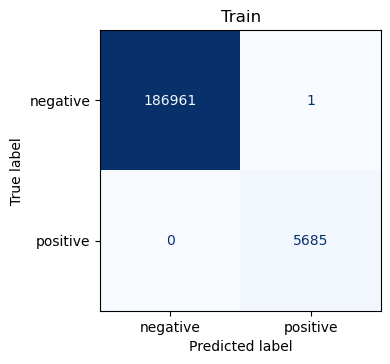

In [18]:
test(
    df=train_df,
    name='Train',
    model_pkl_path=root / 'models' / f'{model_name}.pkl',
    x_col='xtb_concat_3d',
    y_col='cryst',
)



На данной выборке производится сравнение двух типов признаков:
- на основе реальных 3D-геометрий
- на основе восстановленных геометрий

Цель — оценить, насколько реконструкция геометрии влияет на качество предсказания.

Реконструкция не сильно влияет, однако качество оставляет желать лучшего.

Test on real 3D geometries
  F1        : 0.130
  ROC-AUC   : 0.675
  Precision : 0.072
  Recall    : 0.667
Test on reconstructed from 2D geometries
  F1        : 0.129
  ROC-AUC   : 0.652
  Precision : 0.072
  Recall    : 0.608


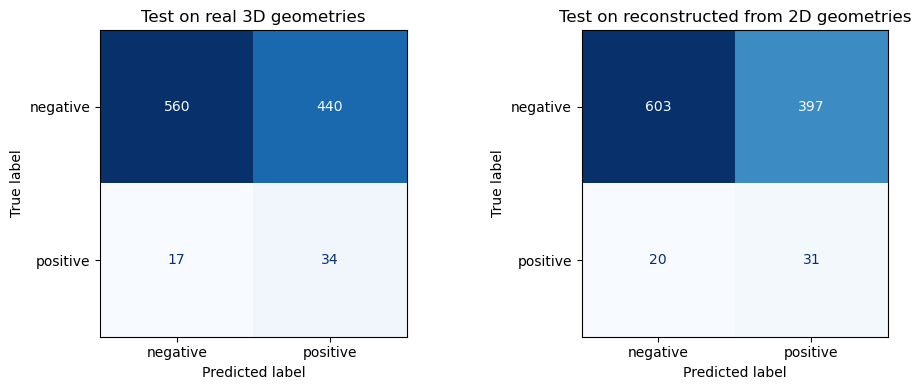

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

test(
    df=holdout_df,
    name='Test on real 3D geometries',
    model_pkl_path=root / 'models' / f'{model_name}.pkl',
    x_col='xtb_concat_3d',
    y_col='cryst',
    ax=axes[0]
)

test(
    df=holdout_df,
    name='Test on reconstructed from 2D geometries',
    model_pkl_path=root / 'models' / f'{model_name}.pkl',
    x_col='xtb_concat_rebuilt',
    y_col='cryst',
    ax=axes[1]
)

plt.tight_layout()
plt.show()

На данной выборке оценивается обобщающая способность модели, так как здесь собраны системы, СИЛЬНО отличающиеся от данных на трейне. Здесь она не справляется и нужен другой подход.

Test on specific systems
  F1        : 0.000
  ROC-AUC   : 0.709
  Precision : 0.000
  Recall    : 0.000


/opt/anaconda3/envs/cocryst_base_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


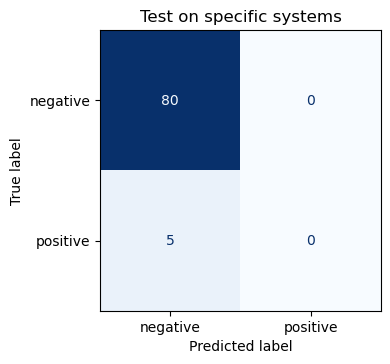

In [20]:
test(
    df=sulf_df,
    name='Test on specific systems',
    model_pkl_path=root / 'models' / f'{model_name}.pkl',
    x_col='xtb_concat_rebuilt',
    y_col='cryst',
)